In [1]:
%pip install pandas matplotlib seaborn langid scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch

print(torch.cuda.is_available())     # True → GPU available
print(torch.cuda.device_count())     # number of GPUs
print(torch.cuda.get_device_name(0))
print(torch.__version__)

True
1
NVIDIA GeForce RTX 4070 Laptop GPU
2.9.1+cu126


In [3]:
import pandas as pd
from  roberta_sentiment import roberta_sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import langid
import unicodedata
import os

vaderAnalyzer = SentimentIntensityAnalyzer()

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


-0.54829144
-0.5027782


In [4]:


files = os.listdir('./data/')

#files = ['12-13-2025_01-52.db', '12-13-2025_22-00.db']
#files  = ['12-17-2025_01-06.db']

print(files)

posts_df = pd.DataFrame()
reposts_df = pd.DataFrame()

for f in files:
    print(f)
    if not f.endswith('db'):
        continue
    con = sqlite3.connect(f'./data/{f}')
    posts = pd.read_sql('SELECT * FROM posts', con)
    posts['dataset'] = f
    reposts = pd.read_sql('SELECT * FROM reposts', con)
    reposts['dataset'] = f
    
    posts_df = pd.concat([posts_df, posts])
    reposts_df = pd.concat([reposts_df, reposts])
    con.close()

posts_df['post_time'] = pd.to_datetime(posts_df['post_time'], format = 'ISO8601')
reposts_df['repost_time'] = pd.to_datetime(reposts_df['time'], format = 'ISO8601')

print(posts_df[::100])
print(reposts_df[::100])
print(len(posts_df))
print(len(reposts_df))

['12-10-2025_20-17.db', '12-12-2025_00-55.db', '12-12-2025_00-58.db', '12-13-2025_01-51.db', '12-13-2025_01-52.db', '12-13-2025_22-00.db', '12-15-2025_22-47.db', '12-15-2025_22-48.db', '12-16-2025_01-10.db', '12-16-2025_12-08.db', '12-16-2025_17-12.db', '12-16-2025_20-31.db', '12-17-2025_01-06.db', '12-17-2025_17-58.db', '12-17-2025_18-00.db', '12-17-2025_18-01.db']
12-10-2025_20-17.db
12-12-2025_00-55.db
12-12-2025_00-58.db
12-13-2025_01-51.db
12-13-2025_01-52.db
12-13-2025_22-00.db
12-15-2025_22-47.db
12-15-2025_22-48.db
12-16-2025_01-10.db
12-16-2025_12-08.db
12-16-2025_17-12.db
12-16-2025_20-31.db
12-17-2025_01-06.db
12-17-2025_17-58.db
12-17-2025_18-00.db
12-17-2025_18-01.db
                                              post_cid  \
0    bafyreiezm6eaphsewzmyfnir34ghbnbggeuomezlhom5o...   
100  bafyreiekrbehjsukfz5pe6iy5iv52oizc2qgtqhulrtis...   
200  bafyreicytu7s6v4iagklwrpt4pvakltm3eyf6hppp7jc3...   
300  bafyreibhyi3mykyerdymjmrzftcgmgf72kseg5bchsox7...   
400  bafyreigcvaayfmt

In [5]:

# import re

# def extract_user_id(uri):
#     if not isinstance(uri, str):
#         return None
#     match = re.search(r"plc:([^/]+)", uri)
#     return match.group(1) if match else None

# posts_df["user_id"] = posts_df["post_uri"].apply(extract_user_id)
# post_counts = posts_df.groupby("user_id").size().reset_index(name="post_count")
# print(post_counts.sort_values('post_count'))
# heavy_users = post_counts[post_counts["post_count"] > 100]["user_id"].tolist()
# print(heavy_users)
# posts_df = posts_df[~posts_df["user_id"].isin(heavy_users)]


<Figure size 1000x500 with 0 Axes>

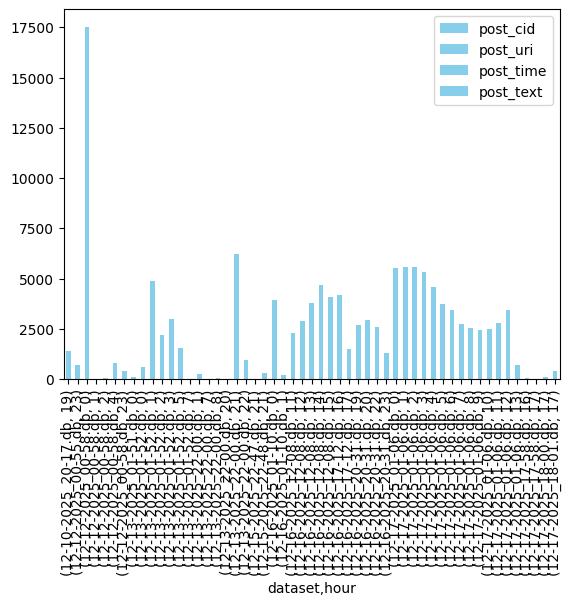

In [6]:

posts_check = posts_df.copy()
posts_check['hour'] = posts_check['post_time'].dt.hour
posts_per_hour = posts_check.groupby(['dataset', 'hour']).count()
posts_check["sentiment"] = posts_check["post_text"].apply(lambda text: vaderAnalyzer.polarity_scores(text).get('compound'))
avg_sentiment_per_hour = posts_check.groupby(['dataset', 'hour'])['sentiment'].mean()

plt.figure(figsize=(10,5))
posts_per_hour.plot(kind='bar', color='skyblue')
plt.show()




In [7]:



def to_plain(text):
    return ''.join(
        c for c in unicodedata.normalize("NFKD", text)
        if not unicodedata.combining(c)
    )



posts_df["post_text"] = posts_df["post_text"].apply(to_plain)
posts_df["lang"] = posts_df["post_text"].apply(lambda x: langid.classify(x)[0])
english_posts = posts_df[posts_df['lang'] == 'en']

first_reposts = (
    reposts_df
        .sort_values("repost_time")
        .groupby("post_cid", as_index=False)
        .first()[["post_cid", "repost_time"]]
)

merged = english_posts.merge(first_reposts, on="post_cid", how="left")

# Count reposts
repost_counts = reposts_df.groupby("post_cid").size().reset_index(name="total_reposts")

# Merge counts into merged
merged = merged.merge(repost_counts, on="post_cid", how="left")
merged["total_reposts"] = merged["total_reposts"].fillna(0)




print(merged)

                                                 post_cid  \
0       bafyreiezm6eaphsewzmyfnir34ghbnbggeuomezlhom5o...   
1       bafyreicapxvkc2rzobbjpsx4e6l232tahs5qpvcrcz5zd...   
2       bafyreibrbeysaajpnlz2jvxkhyhk32ndo6rj4o4fmuy73...   
3       bafyreih2lmy7abz6qcjhunp3xkvrntswnluj4qwlhvebm...   
4       bafyreihm7chw5djo6ckha5zcvhvumbnktiqp6hygd5w6l...   
...                                                   ...   
111966  bafyreifkuabxnvjjqyvyuaxlnx66gw2jhr7rvvr7boyz3...   
111967  bafyreifqwpxe6qmjvfltyvalluuqxwrobddyrykezr43f...   
111968  bafyreiaymyovabh3qncic37xk6iigkdujgvdgvx6mn6pt...   
111969  bafyreifmfj3q3c7oefz3gzqlzdrr5ycyudtbaa5sqkv5l...   
111970  bafyreif5ifxwlpa2fqtz5jk7dgnddp6dgiyltg2vufy5g...   

                                                 post_uri  \
0       at://did:plc:vqmsukyjlpzpj7f2gu6rfrwe/app.bsky...   
1       at://did:plc:6smdztjrq7bjjlojkrnpcnxm/app.bsky...   
2       at://did:plc:cncq7jossmwpcvyxn3cntdx6/app.bsky...   
3       at://did:plc:4e

In [8]:
merged.dtypes

post_cid                      object
post_uri                      object
post_time        datetime64[ns, UTC]
post_text                     object
dataset                       object
lang                          object
repost_time      datetime64[ns, UTC]
total_reposts                float64
dtype: object

In [9]:
print(posts)



merged["sentiment"] = merged["post_text"].apply(lambda text: vaderAnalyzer.polarity_scores(text).get('compound'))

# Calculate time to first repost (timedelta)
merged["time_to_first_repost"] = merged["repost_time"] - merged["post_time"]

# Convert to minutes as numeric
merged["time_to_first_repost_min"] = merged["time_to_first_repost"].dt.total_seconds() / 60

# print(repost_df.info())
# print(post_df.info())
print(merged)

                                              post_cid  \
0    bafyreib7xph3lf7w2ly34y6zvn34ogwlzuybbok4ti75v...   
1    bafyreiac23csarl5ru6izdb223agkbd4uawq3mmyx3hbw...   
2    bafyreibi2izzntins7bhczc6gqboadjnt2flkacfurffi...   
3    bafyreiaul5wnhgswcwqzxgmg2we3zvfkqzzinhyvazvn6...   
4    bafyreieb5x6lmeuxztqlyqn2xi5exujwfoeo7sapoz6dc...   
..                                                 ...   
391  bafyreifu4dgdteuogo6yvrnh2cvplnanacxkb6mig3k52...   
392  bafyreifmfj3q3c7oefz3gzqlzdrr5ycyudtbaa5sqkv5l...   
393  bafyreia6h4xravskhzho2ijkilbg5scp75jyi5otkuimm...   
394  bafyreif5ifxwlpa2fqtz5jk7dgnddp6dgiyltg2vufy5g...   
395  bafyreifz7hxllzkfcuz6yhpij36abzs3jwjz6zthaeegv...   

                                              post_uri  \
0    at://did:plc:6p56eygw6gg5jt6cn7f7qxlw/app.bsky...   
1    at://did:plc:cdgp6fmcqlkns7dj2m6geoc5/app.bsky...   
2    at://did:plc:d6s3db36oz464wscqrmg353q/app.bsky...   
3    at://did:plc:wapj4xspqixpf6twaakbt4xo/app.bsky...   
4    at://did

In [10]:
merged.dtypes

post_cid                                 object
post_uri                                 object
post_time                   datetime64[ns, UTC]
post_text                                object
dataset                                  object
lang                                     object
repost_time                 datetime64[ns, UTC]
total_reposts                           float64
sentiment                               float64
time_to_first_repost            timedelta64[ns]
time_to_first_repost_min                float64
dtype: object

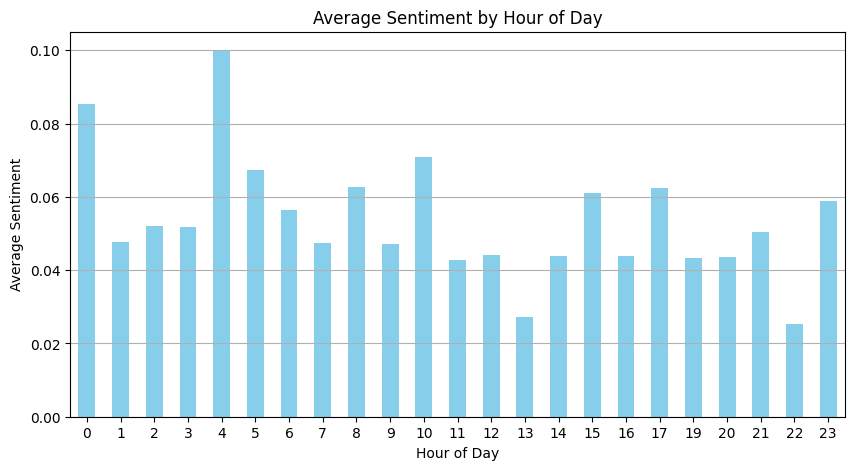

In [11]:
df = merged

df['hour'] = df['post_time'].dt.hour

# 2. Group by hour and compute average sentiment
avg_sentiment_by_hour = df.groupby('hour')['sentiment'].mean()

# 3. Plot
plt.figure(figsize=(10,5))
avg_sentiment_by_hour.plot(kind='bar', color='skyblue')
plt.xlabel('Hour of Day')
plt.ylabel('Average Sentiment')
plt.title('Average Sentiment by Hour of Day')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

all posts: 5814
after no repost remover: 5814
after no less than 5 reposts remover: 5814
after negative remover: 5814


C:\Users\milov\AppData\Local\Temp\ipykernel_21824\2847482888.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_time = df_plot.groupby("sentiment_bin")["time_to_first_repost_min"].mean().reset_index()


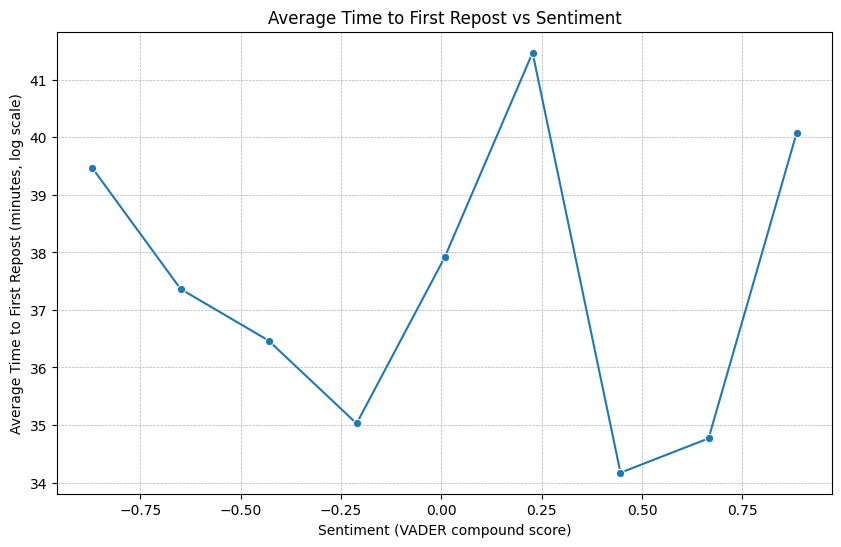

C:\Users\milov\AppData\Local\Temp\ipykernel_21824\2847482888.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df_plot.groupby("sentiment_bin").size().reset_index(name="count")


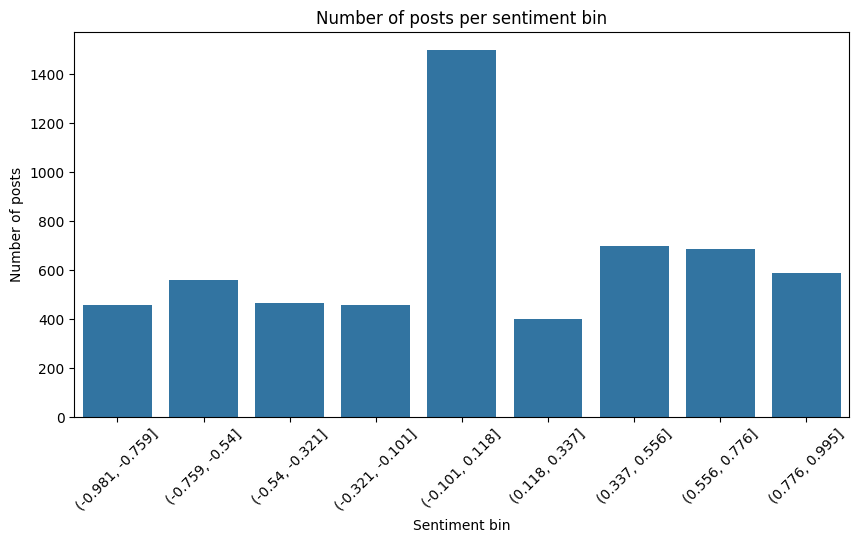

5814


In [16]:
print(f'all posts: {len(merged)}')
# Remove posts without reposts


# Optional: also remove NaN values just to be safe
merged = merged.dropna(subset=["time_to_first_repost_min"])
print(f'after no repost remover: {len(merged)}')

# Filter out posts with more than 5 reposts
merged = merged[merged["total_reposts"] == 1]
print(f'after no less than 5 reposts remover: {len(merged)}')

# Remove rows with negative time_to_first_repost_min
merged = merged[merged["time_to_first_repost_min"] >= 0]
print(f'after negative remover: {len(merged)}')

df_plot = merged.dropna(subset=["time_to_first_repost_min"])


# Optionally, bin sentiment scores into ranges
# VADER sentiment ranges from -1 to 1
num_bins = 9
df_plot["sentiment_bin"] = pd.cut(df_plot["sentiment"], bins=num_bins)

# Compute average time to first repost per sentiment bin
avg_time = df_plot.groupby("sentiment_bin")["time_to_first_repost_min"].mean().reset_index()

# For plotting, use the midpoint of each bin
avg_time["sentiment_mid"] = avg_time["sentiment_bin"].apply(lambda x: x.mid)

# Plot line graph
plt.figure(figsize=(10,6))
sns.lineplot(x="sentiment_mid", y="time_to_first_repost_min", data=avg_time, marker="o")
plt.xlabel("Sentiment (VADER compound score)")
plt.ylabel("Average Time to First Repost (minutes, log scale)")
plt.title("Average Time to First Repost vs Sentiment")
plt.grid(True, which="both", ls="--", lw=0.5)
#plt.ylim(0, 35)  # <-- Set y-axis from 0 to 35
plt.show()

# Count the number of posts per bin
bin_counts = df_plot.groupby("sentiment_bin").size().reset_index(name="count")

plt.figure(figsize=(10,5))
sns.barplot(x="sentiment_bin", y="count", data=bin_counts)
plt.xticks(rotation=45)
plt.xlabel("Sentiment bin")
plt.ylabel("Number of posts")
plt.title("Number of posts per sentiment bin")
plt.show()

print(len(merged))

In [17]:
bin7 = merged[merged['sentiment'].between(0.328, 0.547)]
print(len(bin7))


for index, (_,i) in enumerate(bin7.iterrows()):
    # sentimentt = -0.988 + (index + 0.5) * 0.09442 
    # print(sentimentt)

    print(f"{i['time_to_first_repost_min']} -> {i['post_text']}")

685
3.4524794 -> I used to basically never talk about myself.

I used to think that, my work would speak for itself and that no one cares about me as a person.

It took a long time but I know just how untrue that is now, I have always cared about the artists behind the work, why did I think I'd be different?

1/3
0.3902809666666667 -> Today is a great day for state Attorneys General to bring RICO charges against DHS and ICE for kidnapping and human trafficking!
39.52269078333334 -> LIVE with The Game Awards. My friend @efknee.bsky.social will be joining me since @thelunarnaut.bsky.social PC died. He'll be in chat though.

www.twitch.tv/misterjimmyjam
13.474542033333334 -> Watching the anniversary party ep of Midsomer where Sarah finds out John gave her the dog poop ring and then suddenly in the next episode she is pregnant (WITH BEN'S BABY)
41.659657466666665 -> I will be posting about The Game Awards so you can mute this thread if you need to
9.704288366666667 -> Reminder folks, chatg

In [20]:
def safe_roberta(text):
    try:
        return roberta_sentiment(str(text)[:500])
    except Exception as e:
        print("Error for post:", text[:50], "…", e)
        return None  # or 0 if you prefer

# 1. Compute RoBERTa sentiment for each post
merged["roberta_sentiment"] = merged["post_text"].apply(safe_roberta)

# 2. Ensure time-to-first-repost in minutes
merged["time_to_first_repost_min"] = (merged["repost_time"] - merged["post_time"]).dt.total_seconds() / 60

# 3. Remove invalid or negative times
df_plot = merged.dropna(subset=["roberta_sentiment", "time_to_first_repost_min"])
df_plot = df_plot[df_plot["time_to_first_repost_min"] >= 0]



C:\Users\milov\AppData\Local\Temp\ipykernel_21824\1171901451.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sentiment_bin")["time_to_first_repost_min"]


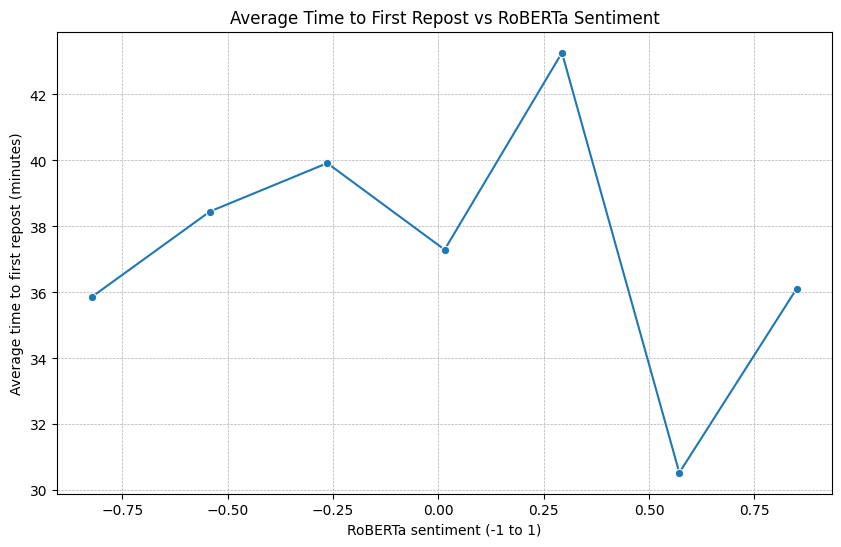

In [24]:
# 4. Bin sentiment and compute average repost time per bin
num_bins = 7
df_plot["sentiment_bin"] = pd.cut(df_plot["roberta_sentiment"], bins=num_bins)

avg_time = (
    df_plot
    .groupby("sentiment_bin")["time_to_first_repost_min"]
    .mean()
    .reset_index()
)
avg_time["sentiment_mid"] = avg_time["sentiment_bin"].apply(lambda x: x.mid)

# 5. Plot line: average time to first repost vs RoBERTa sentiment
plt.figure(figsize=(10,6))
sns.lineplot(
    x="sentiment_mid",
    y="time_to_first_repost_min",
    data=avg_time,
    marker="o"
)

plt.xlabel("RoBERTa sentiment (-1 to 1)")
plt.ylabel("Average time to first repost (minutes)")
plt.title("Average Time to First Repost vs RoBERTa Sentiment")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

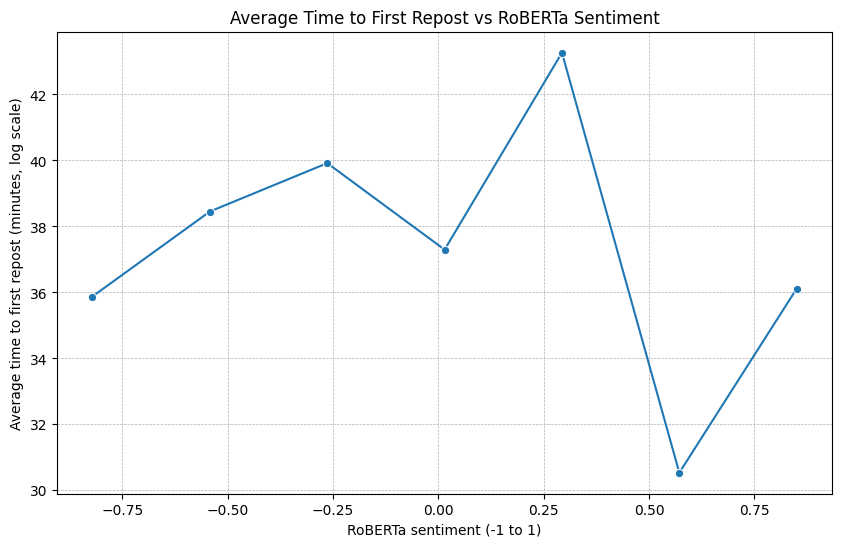

C:\Users\milov\AppData\Local\Temp\ipykernel_21824\1291860385.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df_plot.groupby("sentiment_bin").size().reset_index(name="count")


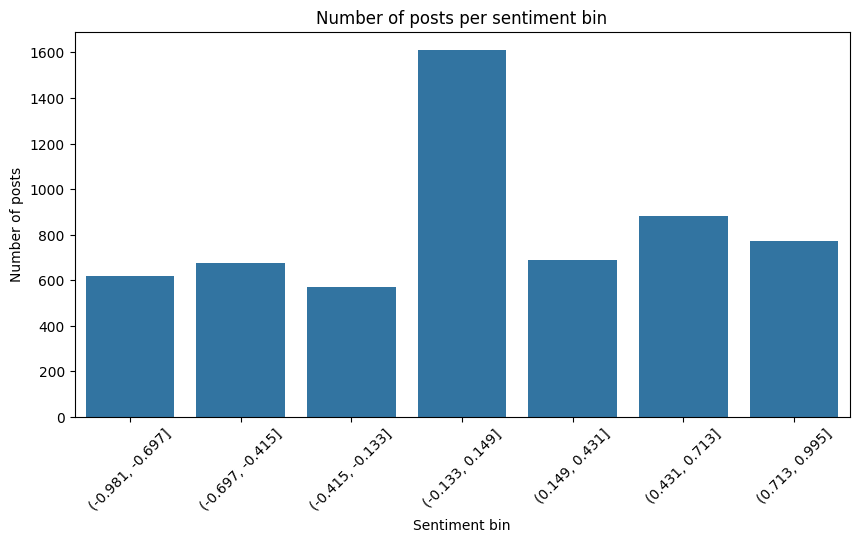

In [27]:
avg_time["sentiment_mid"] = avg_time["sentiment_bin"].apply(lambda x: x.mid)

# 5. Plot line: average time to first repost vs RoBERTa sentiment
plt.figure(figsize=(10,6))
sns.lineplot(
    x="sentiment_mid",
    y="time_to_first_repost_min",
    data=avg_time,
    marker="o"
)
plt.xlabel("RoBERTa sentiment (-1 to 1)")
plt.ylabel("Average time to first repost (minutes, log scale)")
plt.title("Average Time to First Repost vs RoBERTa Sentiment")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

bin_counts = df_plot.groupby("sentiment_bin").size().reset_index(name="count")

plt.figure(figsize=(10,5))
sns.barplot(x="sentiment_bin", y="count", data=bin_counts)
plt.xticks(rotation=45)
plt.xlabel("Sentiment bin")
plt.ylabel("Number of posts")
plt.title("Number of posts per sentiment bin")
plt.show()

C:\Users\milov\AppData\Local\Temp\ipykernel_21824\1143451476.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_plot.groupby("sentiment_bin").agg(


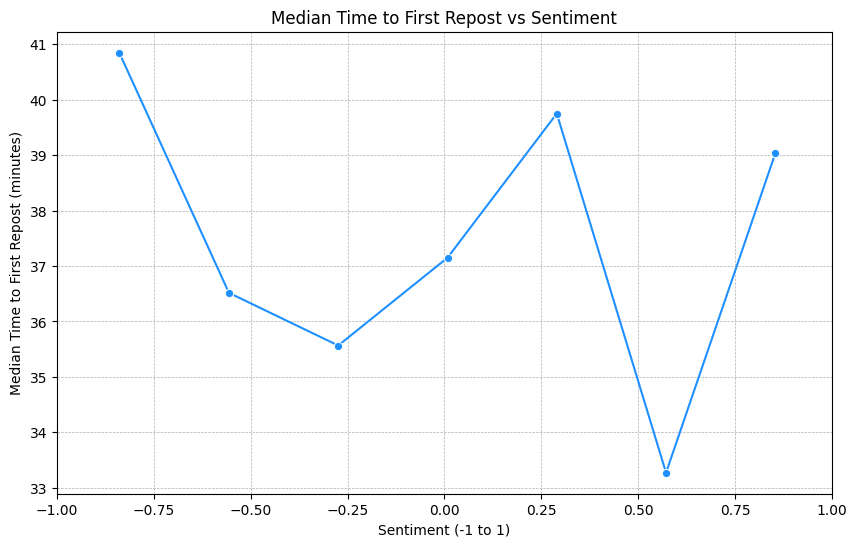

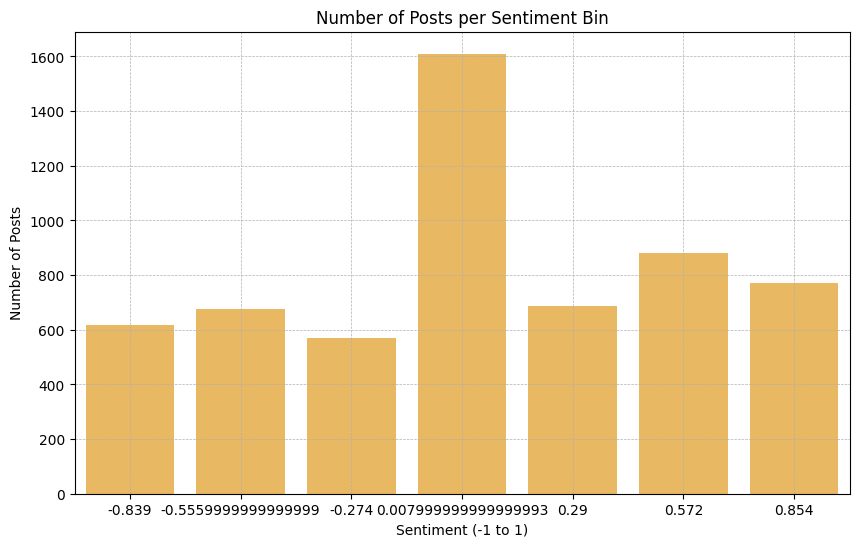

: 

In [ ]:
# Ensure only valid times
df_plot = merged.dropna(subset=["time_to_first_repost_min"])
df_plot = df_plot[df_plot["time_to_first_repost_min"] >= 0]

# Use fewer bins for small dataset
num_bins = 7
df_plot["sentiment_bin"] = pd.cut(df_plot["sentiment"], bins=num_bins)

# Compute median time and post count per bin
bin_stats = df_plot.groupby("sentiment_bin").agg(
    median_time=("time_to_first_repost_min", "mean"),
    post_count=("post_text", "count")
).reset_index()

# Compute bin midpoint for plotting
bin_stats["sentiment_mid"] = bin_stats["sentiment_bin"].apply(lambda x: x.mid)

# --- Plot 1: Median time to first repost ---
plt.figure(figsize=(10,6))
sns.lineplot(
    x="sentiment_mid",
    y="median_time",
    data=bin_stats,
    marker="o",
    color="dodgerblue"
)
plt.xlabel("Sentiment (-1 to 1)")
plt.ylabel("Median Time to First Repost (minutes)")
plt.title("Median Time to First Repost vs Sentiment")
plt.grid(True, ls="--", lw=0.5)
plt.xlim(-1, 1)
plt.show()

# --- Plot 2: Number of posts per sentiment bin ---
plt.figure(figsize=(10,6))
sns.barplot(
    x="sentiment_mid",
    y="post_count",
    data=bin_stats,
    color="orange",
    alpha=0.7
)
plt.xlabel("Sentiment (-1 to 1)")
plt.ylabel("Number of Posts")
plt.title("Number of Posts per Sentiment Bin")
plt.grid(True, ls="--", lw=0.5)
plt.show()